In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv("D:/flipkart_fake_review/Data/processed_reviews.csv")
df.head()

,Product_name,Price,Rate,Review,Summary,review_length,word_count,caps_ratio,avg_word_length,sentiment_score,...,repetition_flag,generic_flag,rating_mismatch_flag,duplicate_flag,meaningless_flag,caps_ratio_flag,exact_duplicate,fraud_score,fake_status,ml_prediction
0,Crompton 75 L Desert Air Cooler(White Teal ACG...,10499.0,5.0,Simply awesome,it's really worth every single penny. it works...,485,89,0.023438,4.460674,0.2940,...,0,0,0,0,0,0,True,0,Genuine,Genuine
1,Crompton 75 L Desert Air Cooler(White Teal ACG...,10499.0,4.0,Worth the money . Desert Cooler live up to the...,I bought Crompton Ozone 75 Desert Air Cooler i...,492,101,0.060773,3.881188,0.4481,...,0,0,0,0,0,0,True,0,Genuine,Genuine
2,Crompton 75 L Desert Air Cooler(White Teal ACG...,10499.0,5.0,Worth every penny,GREAT packaging by seller. As this was the mos...,499,86,0.035443,4.813953,0.3181,...,0,0,0,0,0,0,True,0,Genuine,Genuine
3,Crompton 75 L Desert Air Cooler(White Teal ACG...,10499.0,5.0,Fabulous!,Delivery was delayed by two days except this e...,404,68,0.006173,4.955882,0.3545,...,0,0,0,0,0,0,True,0,Genuine,Genuine
4,Crompton 75 L Desert Air Cooler(White Teal ACG...,10499.0,4.0,Nice product,A Good cooler by Crompton. The height of the c...,487,104,0.022989,3.692308,0.3318,...,0,0,0,0,0,0,True,0,Genuine,Genuine


In [4]:
df.info()

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363236 entries, 0 to 363235
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Product_name          363220 non-null  object 
 1   Price                 363214 non-null  float64
 2   Rate                  363236 non-null  float64
 3   Review                363214 non-null  object 
 4   Summary               361214 non-null  object 
 5   review_length         363236 non-null  int64  
 6   word_count            363236 non-null  int64  
 7   caps_ratio            363236 non-null  float64
 8   avg_word_length       363236 non-null  float64
 9   sentiment_score       363236 non-null  float64
 10  sentiment_label       363236 non-null  object 
 11  length_flag           363236 non-null  int64  
 12  repetition_flag       363236 non-null  int64  
 13  generic_flag          363236 non-null  int64  
 14  rating_mismatch_flag  363236 non-null  int64  
 15  

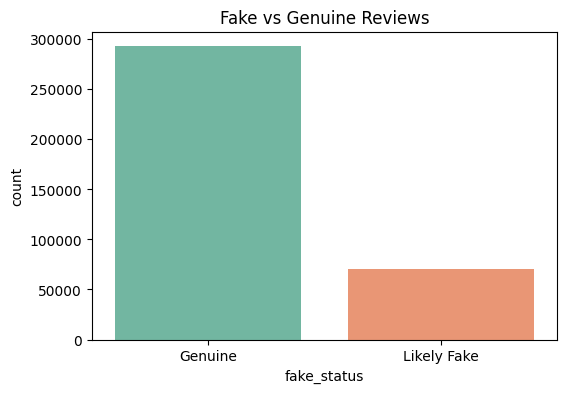

In [5]:
# Target Variable Distribution
df['fake_status'].value_counts(normalize=True)*100

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='fake_status', palette='Set2')

plt.title('Fake vs Genuine Reviews')
plt.show()

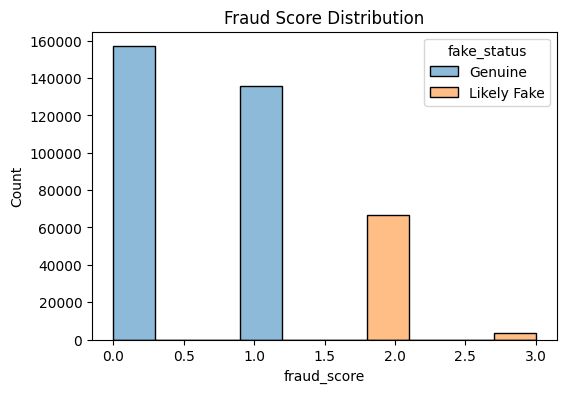

In [6]:
# Fraud Score Distribution
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="fraud_score", hue="fake_status", bins=10)

plt.title("Fraud Score Distribution")
plt.show()

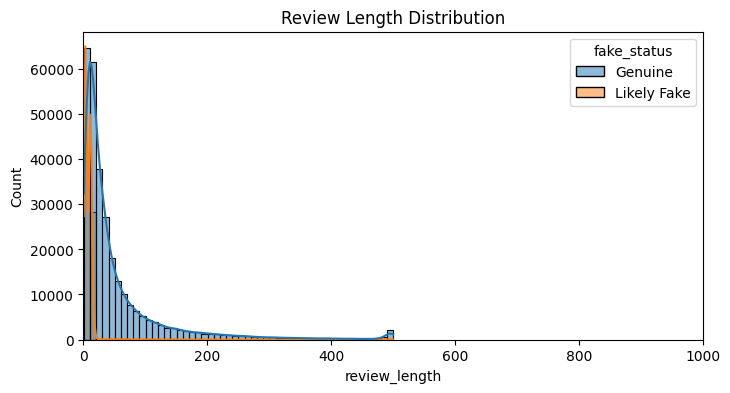

In [7]:
# Review Length Distribution
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='review_length', hue='fake_status', bins=50, kde=True)

plt.xlim(0, 1000)
plt.title('Review Length Distribution')

plt.show()

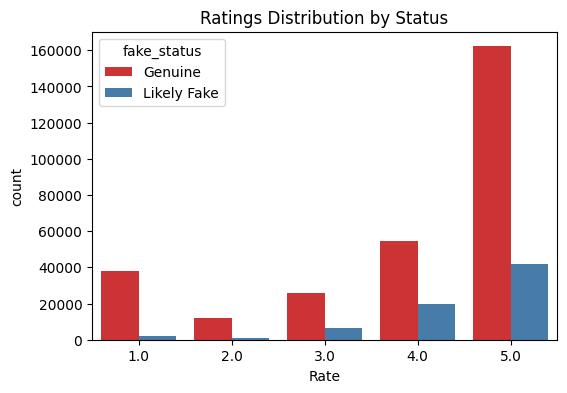

In [8]:
# Ratings vs Fake Status
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Rate', hue='fake_status', palette='Set1')

plt.title('Ratings Distribution by Status')
plt.show()

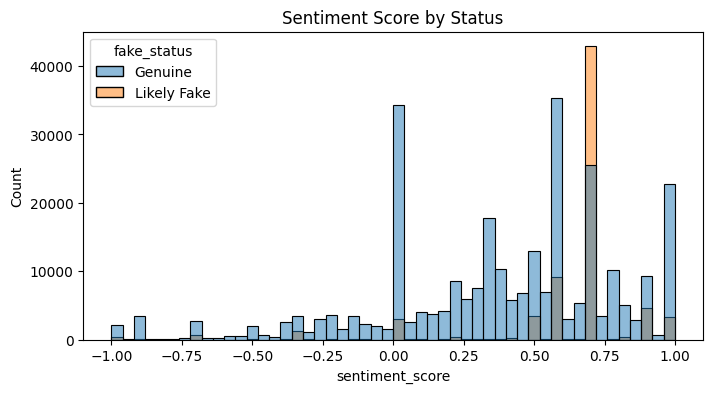

In [9]:
# Sentiment Score Analysis
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='sentiment_score', hue='fake_status', bins=50)

plt.title('Sentiment Score by Status')
plt.show()

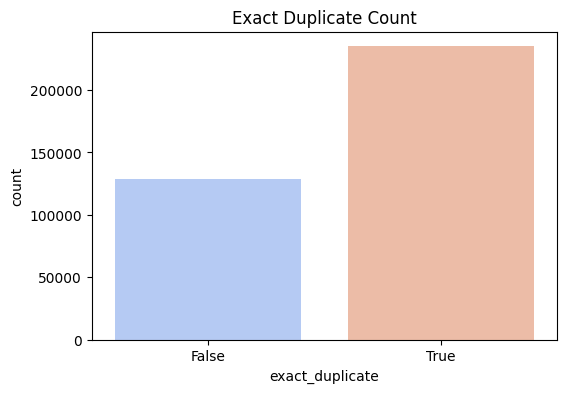

In [10]:
# Duplicate Reviews Analysis
if 'exact_duplicate' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x='exact_duplicate', palette='coolwarm')

    plt.title('Exact Duplicate Count')
    plt.show()

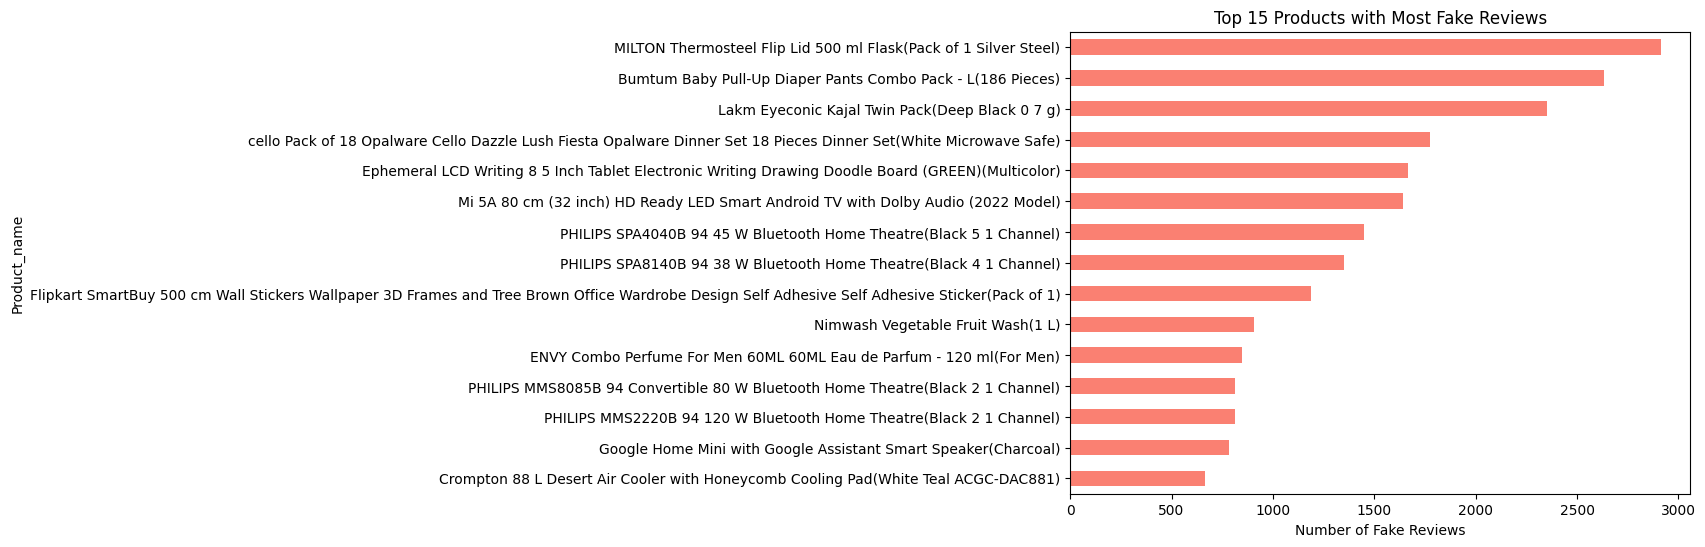

In [ ]:
# Top Products with Fake Reviews
plt.figure(figsize=(8,6))

fake_df = df[df['fake_status'].isin(['Likely Fake', 'Suspicious'])]

fake_df['Product_name'].value_counts().head(15).sort_values().plot(
    kind='barh',
    color='salmon'
)

plt.title('Top 15 Products with Most Fake Reviews')
plt.xlabel('Number of Fake Reviews')

plt.show()

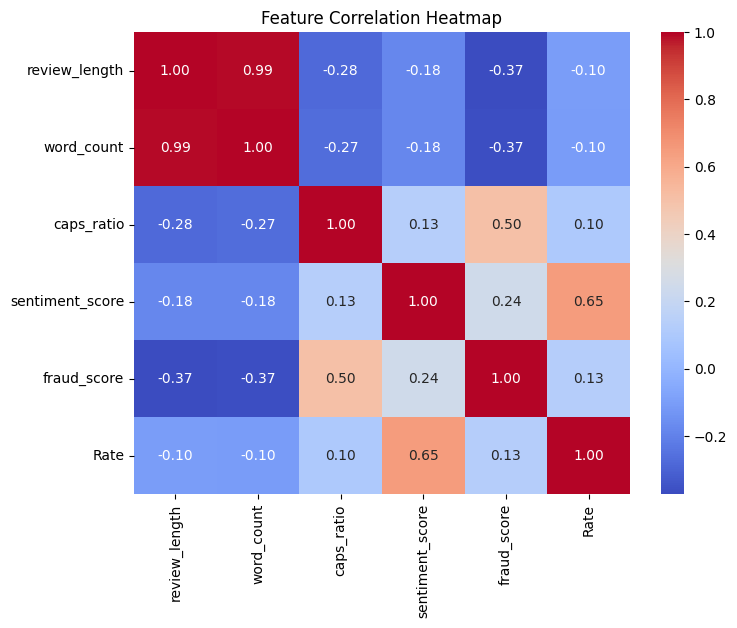

In [12]:
# Feature Correlation Heatmap
numeric_cols = ['review_length', 'word_count', 'caps_ratio', 'sentiment_score', 'fraud_score', 'Rate']
existing_cols = [c for c in numeric_cols if c in df.columns]

plt.figure(figsize=(8,6))
sns.heatmap(df[existing_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Feature Correlation Heatmap')
plt.show()

In [13]:
# Prepare Features for Machine Learning
features = ["review_length", "word_count", "caps_ratio", "sentiment_score"]

X = df[features]
y = (df["fake_status"] == "Likely Fake").astype(int)

In [14]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [15]:
# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8258727012443563


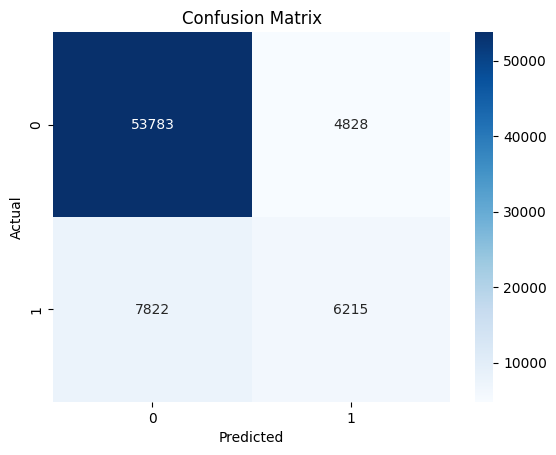

In [16]:
# Confusion Matrix
preds = model.predict(X_test)

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

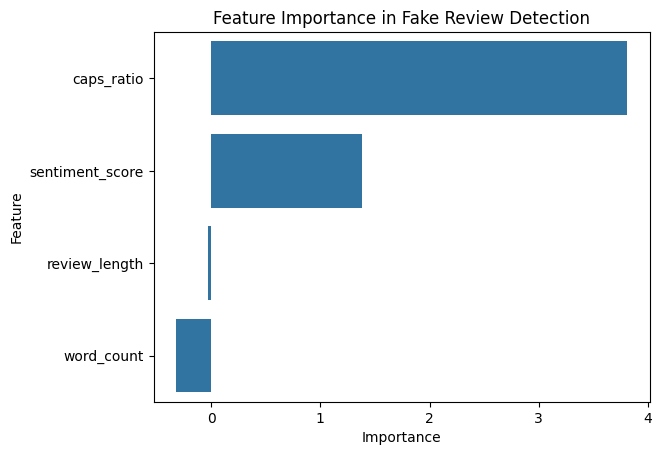

In [17]:
# Feature Importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.coef_[0]
}).sort_values(by="Importance", ascending=False)

sns.barplot(data=importance, x="Importance", y="Feature")

plt.title("Feature Importance in Fake Review Detection")
plt.show()

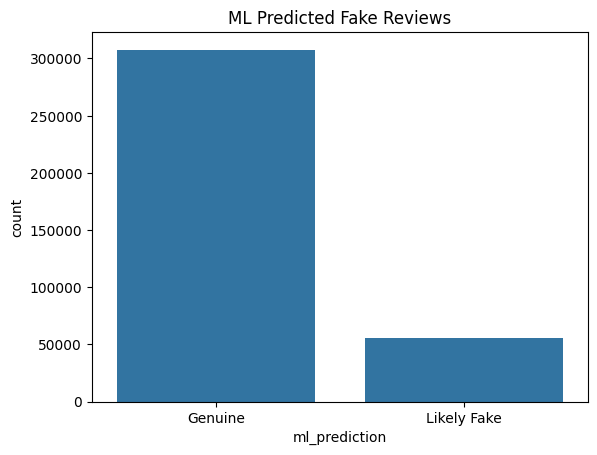

In [18]:
# ML Predictions Distribution
sns.countplot(data=df, x='ml_prediction')
plt.title("ML Predicted Fake Reviews")
plt.show()